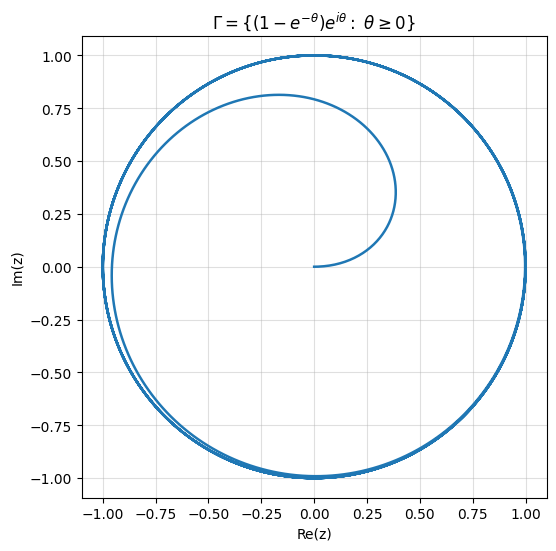

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetro (más grande -> más vueltas)
theta = np.linspace(0, 12*np.pi, 4000)

# Arco Γ : z(θ) = (1 - e^{-θ}) e^{iθ}
z = (1 - np.exp(-theta)) * np.exp(1j * theta)

# Gráfica en el plano complejo
plt.figure(figsize=(6,6))
plt.plot(z.real, z.imag, lw=1.8)
plt.axis('equal')
plt.grid(True, alpha=0.4)
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.title(r'$\Gamma=\{(1-e^{-\theta})e^{i\theta}:\ \theta\geq 0\}$')
plt.show()

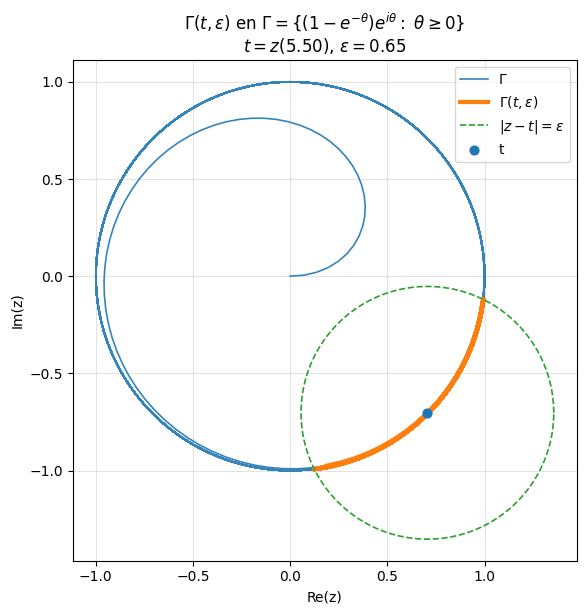

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ==================== Parámetros ====================
theta_max = 120*np.pi   # cuántas vueltas de la curva
n_samples = 5000       # resolución de la muestra
theta0     = 5.5       # elige el punto t mediante θ0 (en radianes)
eps        = 0.65      # radio ε del disco
# ====================================================

def gamma_theta(th):
    """Curva Γ parametrizada: z(θ) = (1 - e^{-θ}) e^{iθ}."""
    return (1 - np.exp(-th)) * np.exp(1j * th)

# Curva completa
theta = np.linspace(0, theta_max, n_samples)
z = gamma_theta(theta)

# Punto t en la curva y disco ε
t = gamma_theta(theta0)

# Subconjunto Γ(t, ε) = {τ ∈ Γ : |τ - t| < ε}
mask = np.abs(z - t) < eps

# Usamos NaN para romper líneas fuera del disco
xh = np.where(mask, z.real, np.nan)
yh = np.where(mask, z.imag, np.nan)

# Circunferencia |z - t| = ε
phi = np.linspace(0, 2*np.pi, 720)
circle = t + eps * (np.cos(phi) + 1j*np.sin(phi))

# ----- Gráfica -----
plt.figure(figsize=(6.5, 6.5))
plt.plot(z.real, z.imag, lw=1.2, alpha=0.9, label='Γ')
plt.plot(xh, yh, lw=3, label=r'$\Gamma(t,\varepsilon)$')
plt.plot(circle.real, circle.imag, '--', lw=1.2, label=r'$|z-t| = \varepsilon$')
plt.scatter([t.real], [t.imag], s=40, zorder=3, label='t')

plt.axis('equal'); plt.grid(True, alpha=0.35)
plt.xlabel('Re(z)'); plt.ylabel('Im(z)')
plt.title(r'$\Gamma(t,\varepsilon)$ en $\Gamma=\{(1-e^{-\theta})e^{i\theta}:\ \theta \geq 0\}$'
          f'\n$t=z({theta0:.2f})$, $\\varepsilon={eps}$')
plt.legend()
plt.show()


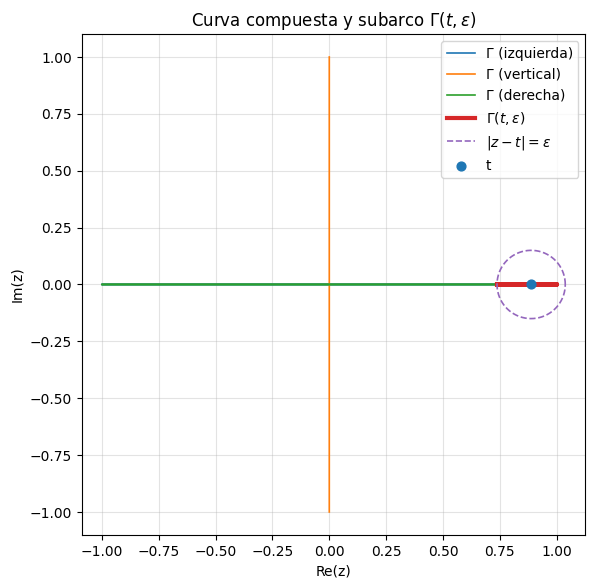

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# =================== Parámetros ===================
N1, N2, N3 = 4000, 4000, 1200     # resolución por rama
x_gap = 1e-9                       # evita x=0
branch = 'left'                   # 'left' | 'vertical' | 'right'
x0 = -0.12                          # si branch='left' o 'right'
y0 = 0.40                          # si branch='vertical'
eps = 0.15                         # radio ε
# ==================================================

# --- Ramas de Γ ---
x_left  = np.linspace(-1, -x_gap, N1)
z_left  = np.sin(1/np.abs(x_left)) + 0j

y_vert  = np.linspace(-1, 1, N3)
z_vert  = 1j*y_vert

x_right = np.linspace(x_gap, 1, N2)
z_right = np.sin(1/x_right) + 0j

def join_with_nans(segments):
    out = []
    for s in segments:
        out.append(s)
        out.append(np.array([np.nan + 1j*np.nan]))
    return np.concatenate(out)

# Para la máscara trabajamos con todas las muestras (con NaNs que cortan líneas)
z_all = join_with_nans([z_left, z_vert, z_right])

# --- Elige t de forma segura según la rama ---
def pick_t(branch, x0, y0):
    if branch == 'left':
        # x en [-1, -x_gap]
        x = float(x0)
        x = np.clip(x, -1, -x_gap)
        return np.sin(1/abs(x)) + 0j
    elif branch == 'right':
        # x en [x_gap, 1]
        x = float(x0)
        x = np.clip(x, x_gap, 1.0)
        return np.sin(1/x) + 0j
    elif branch == 'vertical':
        y = float(np.clip(y0, -1, 1))
        return 1j*y
    else:
        raise ValueError("branch debe ser 'left', 'vertical' o 'right'")

t = pick_t(branch, x0, y0)

# --- Subarco Γ(t, ε) ---
mask = np.abs(z_all - t) < eps
xh = np.where(mask, z_all.real, np.nan)
yh = np.where(mask, z_all.imag, np.nan)

# Circunferencia |z - t| = ε
phi = np.linspace(0, 2*np.pi, 600)
circle = t + eps * (np.cos(phi) + 1j*np.sin(phi))

# ----------------- Gráfica -----------------
plt.figure(figsize=(6.5, 6.5))
# Dibuja cada rama por separado (sin unir con segmentos rectos)
plt.plot(z_left.real,  z_left.imag,  lw=1.2, label='Γ (izquierda)')
plt.plot(z_vert.real,  z_vert.imag,  lw=1.2, label='Γ (vertical)')
plt.plot(z_right.real, z_right.imag, lw=1.2, label='Γ (derecha)')

# Resalta Γ(t, ε)
plt.plot(xh, yh, lw=3, label=r'$\Gamma(t,\varepsilon)$')

# Disco ε y punto t
plt.plot(circle.real, circle.imag, '--', lw=1.2, label=r'$|z-t|=\varepsilon$')
plt.scatter([t.real], [t.imag], s=40, zorder=3, label='t')

plt.axis('equal'); plt.grid(True, alpha=0.35)
plt.xlabel('Re(z)'); plt.ylabel('Im(z)')
plt.title('Curva compuesta y subarco $\\Gamma(t,\\varepsilon)$')
plt.legend()
plt.show()
